In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()
RESULTS_DIR = PROJECT_ROOT / "results" / "tables"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

dfi_path = RESULTS_DIR / "GSE238110_dfi_univariate_cox_top5000var.csv"
os_path = RESULTS_DIR / "GSE238110_os_univariate_cox_top5000var.csv"

dfi = pd.read_csv(dfi_path)
osr = pd.read_csv(os_path)

print("DFI results:", dfi.shape)
print("OS results:", osr.shape)

display(dfi.head())
display(osr.head())


DFI results: (5000, 14)
OS results: (5000, 14)


,gene,gene_symbol_clean,n,events,coef,hr_per_sd,se_coef,z,p,ci_lower,ci_upper,c_index,error,q
0,CYP4V2_3,CYP4V2,186,143,-0.427977,0.651826,0.080962,-5.286175,1.249002e-07,0.556182,0.763917,0.660155,NaN,0.000625
1,FMO5_3,FMO5,186,143,-0.378535,0.684864,0.079671,-4.751227,2.021861e-06,0.585852,0.800609,0.630441,NaN,0.003678
2,MEX3A_3,MEX3A,186,143,0.432622,1.541293,0.091447,4.730840,2.235926e-06,1.288384,1.843848,0.616922,NaN,0.003678
3,TRIP13_3,TRIP13,186,143,0.385792,1.470778,0.083707,4.608820,4.049608e-06,1.248232,1.733001,0.624647,NaN,0.003678
4,APOBEC3Z3_4,APOBEC3Z3,186,143,-0.396102,0.672938,0.087137,-4.545743,5.474186e-06,0.567289,0.798263,0.637201,NaN,0.003678


,gene,gene_symbol_clean,n,events,coef,hr_per_sd,se_coef,z,p,ci_lower,ci_upper,c_index,error,q
0,CYP4V2_3,CYP4V2,186,124,-0.433520,0.648223,0.089511,-4.843190,0.000001,0.543917,0.772533,0.664668,NaN,0.006389
1,NIBAN1_3,NIBAN1,186,124,-0.413336,0.661440,0.094346,-4.381049,0.000012,0.549772,0.795790,0.631406,NaN,0.029354
2,CSRP1_3,CSRP1,186,124,-0.427008,0.652458,0.102017,-4.185638,0.000028,0.534214,0.796875,0.628288,NaN,0.029354
3,GPR34_3,GPR34,186,124,-0.391796,0.675842,0.094521,-4.145053,0.000034,0.561550,0.813396,0.631247,NaN,0.029354
4,SAMD9L_3,SAMD9L,186,124,-0.386138,0.679677,0.094601,-4.081765,0.000045,0.564648,0.818138,0.623651,NaN,0.029354


In [2]:
def clean_results(df, endpoint):
    out = df.copy()
    out["endpoint"] = endpoint
    
    if "error" not in out.columns:
        out["error"] = ""
    
    out["error"] = out["error"].fillna("")
    out["fit_ok"] = out["error"].eq("")
    
    for col in ["p", "q", "coef", "hr_per_sd", "c_index"]:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")
    
    out["direction"] = np.where(out["coef"] > 0, "risk", "protective")
    out["abs_coef"] = out["coef"].abs()
    
    return out


dfi_clean = clean_results(dfi, "DFI")
os_clean = clean_results(osr, "OS")

summary = []

for name, df in [("DFI", dfi_clean), ("OS", os_clean)]:
    ok = df[df["fit_ok"]].copy()
    summary.append({
        "endpoint": name,
        "total_genes": df.shape[0],
        "successful_fits": ok.shape[0],
        "failed_fits": int((~df["fit_ok"]).sum()),
        "p_lt_0_05": int((ok["p"] < 0.05).sum()),
        "q_lt_0_25": int((ok["q"] < 0.25).sum()),
        "q_lt_0_10": int((ok["q"] < 0.10).sum()),
        "median_c_index": ok["c_index"].median(),
        "max_c_index": ok["c_index"].max(),
    })

summary = pd.DataFrame(summary)
display(summary)


,endpoint,total_genes,successful_fits,failed_fits,p_lt_0_05,q_lt_0_25,q_lt_0_10,median_c_index,max_c_index
0,DFI,5000,5000,0,1423,1829,874,0.534765,0.660155
1,OS,5000,5000,0,1048,1075,362,0.533241,0.664668


In [3]:
top_n = 30

print("Top DFI genes")
display(
    dfi_clean[dfi_clean["fit_ok"]]
    .sort_values("p")
    .head(top_n)[["gene", "gene_symbol_clean", "hr_per_sd", "coef", "p", "q", "c_index", "direction"]]
)

print("Top OS genes")
display(
    os_clean[os_clean["fit_ok"]]
    .sort_values("p")
    .head(top_n)[["gene", "gene_symbol_clean", "hr_per_sd", "coef", "p", "q", "c_index", "direction"]]
)


Top DFI genes


,gene,gene_symbol_clean,hr_per_sd,coef,p,q,c_index,direction
0,CYP4V2_3,CYP4V2,0.651826,-0.427977,1.249002e-07,0.000625,0.660155,protective
1,FMO5_3,FMO5,0.684864,-0.378535,2.021861e-06,0.003678,0.630441,protective
2,MEX3A_3,MEX3A,1.541293,0.432622,2.235926e-06,0.003678,0.616922,risk
3,TRIP13_3,TRIP13,1.470778,0.385792,4.049608e-06,0.003678,0.624647,risk
4,APOBEC3Z3_4,APOBEC3Z3,0.672938,-0.396102,5.474186e-06,0.003678,0.637201,protective
5,GPR34_3,GPR34,0.675881,-0.391738,6.018807e-06,0.003678,0.627544,protective
6,DNA2_3,DNA2,1.483064,0.394110,6.485603e-06,0.003678,0.619150,risk
7,CBX7_3,CBX7,0.677332,-0.389593,6.780793e-06,0.003678,0.634007,protective
8,LOC477699_3,LOC477699,0.691773,-0.368497,6.850632e-06,0.003678,0.605556,protective
9,ZMAT1_3,ZMAT1,0.687377,-0.374873,7.356664e-06,0.003678,0.625650,protective


Top OS genes


,gene,gene_symbol_clean,hr_per_sd,coef,p,q,c_index,direction
0,CYP4V2_3,CYP4V2,0.648223,-0.433520,0.000001,0.006389,0.664668,protective
1,NIBAN1_3,NIBAN1,0.661440,-0.413336,0.000012,0.029354,0.631406,protective
2,CSRP1_3,CSRP1,0.652458,-0.427008,0.000028,0.029354,0.628288,protective
3,GPR34_3,GPR34,0.675842,-0.391796,0.000034,0.029354,0.631247,protective
4,SAMD9L_3,SAMD9L,0.679677,-0.386138,0.000045,0.029354,0.623651,protective
5,KCTD12_3,KCTD12,0.691312,-0.369164,0.000049,0.029354,0.613416,protective
6,TLR7_3,TLR7,0.696152,-0.362187,0.000050,0.029354,0.626049,protective
7,TDRD7_3,TDRD7,0.676656,-0.390592,0.000059,0.029354,0.614216,protective
8,PTEN_3,PTEN,0.691645,-0.368683,0.000060,0.029354,0.594547,protective
9,EVI2B_3,EVI2B,0.685390,-0.377767,0.000060,0.029354,0.634445,protective


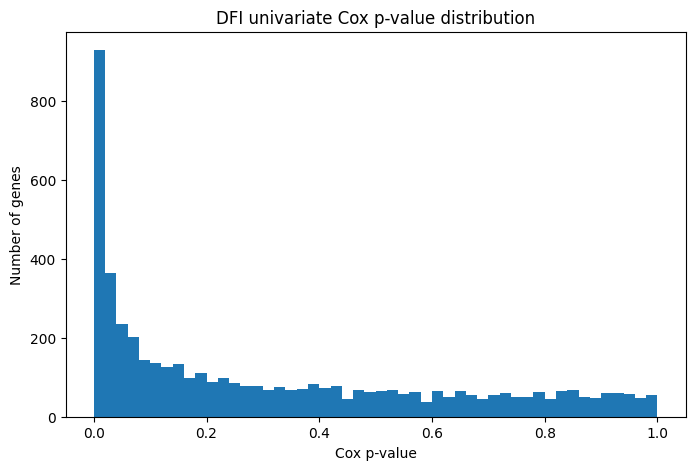

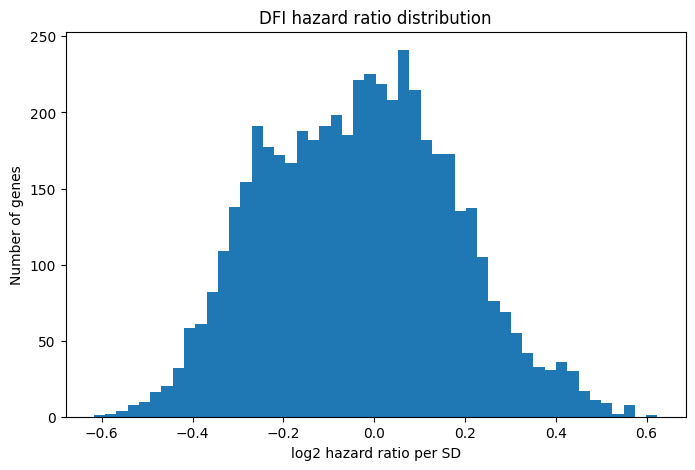

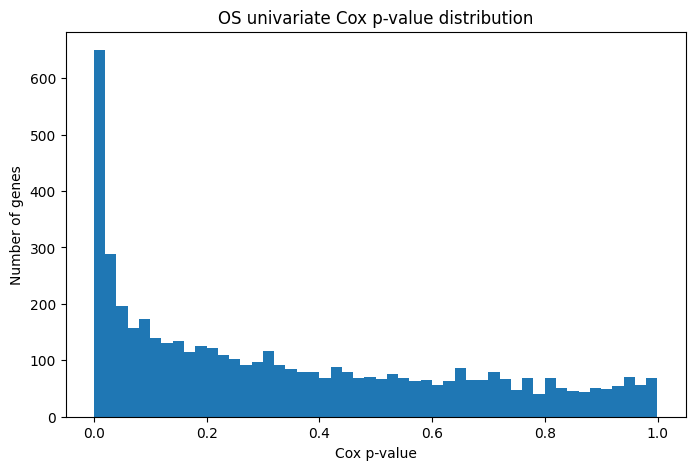

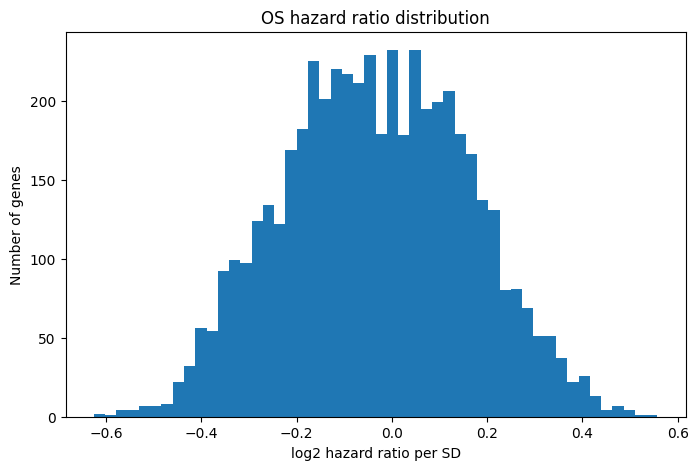

In [4]:
for name, df in [("DFI", dfi_clean), ("OS", os_clean)]:
    ok = df[df["fit_ok"]].copy()

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(ok["p"].dropna(), bins=50)
    ax.set_xlabel("Cox p-value")
    ax.set_ylabel("Number of genes")
    ax.set_title(f"{name} univariate Cox p-value distribution")
    plt.show()

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(np.log2(ok["hr_per_sd"].replace([np.inf, -np.inf], np.nan)).dropna(), bins=50)
    ax.set_xlabel("log2 hazard ratio per SD")
    ax.set_ylabel("Number of genes")
    ax.set_title(f"{name} hazard ratio distribution")
    plt.show()


In [5]:
dfi_ranked = dfi_clean[dfi_clean["fit_ok"]].sort_values("p").copy()
os_ranked = os_clean[os_clean["fit_ok"]].sort_values("p").copy()

overlap_rows = []

for n in [50, 100, 200, 300, 500, 1000]:
    dfi_top = set(dfi_ranked.head(n)["gene"])
    os_top = set(os_ranked.head(n)["gene"])
    overlap = dfi_top & os_top
    
    merged_top = dfi_ranked[["gene", "coef"]].merge(
        os_ranked[["gene", "coef"]],
        on="gene",
        suffixes=("_dfi", "_os")
    )
    merged_top = merged_top[merged_top["gene"].isin(overlap)].copy()
    
    if merged_top.shape[0] > 0:
        same_direction = (np.sign(merged_top["coef_dfi"]) == np.sign(merged_top["coef_os"])).sum()
    else:
        same_direction = 0
    
    overlap_rows.append({
        "top_n": n,
        "dfi_top_n": len(dfi_top),
        "os_top_n": len(os_top),
        "overlap": len(overlap),
        "same_direction_overlap": int(same_direction),
    })

overlap_summary = pd.DataFrame(overlap_rows)
display(overlap_summary)


,top_n,dfi_top_n,os_top_n,overlap,same_direction_overlap
0,50,50,50,21,21
1,100,100,100,51,51
2,200,200,200,120,120
3,300,300,300,181,181
4,500,500,500,343,343
5,1000,1000,1000,734,734


In [6]:
merged = dfi_clean[dfi_clean["fit_ok"]][
    ["gene", "gene_symbol_clean", "coef", "hr_per_sd", "p", "q", "c_index"]
].merge(
    os_clean[os_clean["fit_ok"]][
        ["gene", "coef", "hr_per_sd", "p", "q", "c_index"]
    ],
    on="gene",
    suffixes=("_dfi", "_os")
)

merged["same_direction"] = np.sign(merged["coef_dfi"]) == np.sign(merged["coef_os"])
merged["combined_rank_score"] = merged["p_dfi"].rank() + merged["p_os"].rank()

print("Merged DFI/OS genes:", merged.shape)
print("Same direction:", merged["same_direction"].sum())

display(
    merged.sort_values("combined_rank_score")
    .head(50)
)


Merged DFI/OS genes: (5000, 14)
Same direction: 4441


,gene,gene_symbol_clean,coef_dfi,hr_per_sd_dfi,p_dfi,q_dfi,c_index_dfi,coef_os,hr_per_sd_os,p_os,q_os,c_index_os,same_direction,combined_rank_score
0,CYP4V2_3,CYP4V2,-0.427977,0.651826,1.249002e-07,0.000625,0.660155,-0.433520,0.648223,0.000001,0.006389,0.664668,True,2.0
5,GPR34_3,GPR34,-0.391738,0.675881,6.018807e-06,0.003678,0.627544,-0.391796,0.675842,0.000034,0.029354,0.631247,True,10.0
21,NIBAN1_3,NIBAN1,-0.364941,0.694238,2.461232e-05,0.005559,0.618927,-0.413336,0.661440,0.000012,0.029354,0.631406,True,24.0
13,ATAD1_3,ATAD1,-0.369476,0.691097,1.338031e-05,0.004623,0.575249,-0.353559,0.702185,0.000104,0.034762,0.585992,True,29.0
2,MEX3A_3,MEX3A,0.432622,1.541293,2.235926e-06,0.003678,0.616922,0.341269,1.406731,0.000256,0.045277,0.614856,True,30.0
3,TRIP13_3,TRIP13,0.385792,1.470778,4.049608e-06,0.003678,0.624647,0.334060,1.396627,0.000252,0.045277,0.605661,True,30.0
19,EVI2B_3,EVI2B,-0.361211,0.696832,2.363434e-05,0.005559,0.630070,-0.377767,0.685390,0.000060,0.029354,0.634445,True,30.0
14,TSPAN33_3,TSPAN33,0.398156,1.489076,1.386821e-05,0.004623,0.589660,0.360415,1.433924,0.000128,0.035464,0.592148,True,33.0
1,FMO5_3,FMO5,-0.378535,0.684864,2.021861e-06,0.003678,0.630441,-0.310540,0.733051,0.000303,0.045277,0.622292,True,34.0
27,KCTD12_3,KCTD12,-0.341036,0.711033,3.536471e-05,0.006315,0.614025,-0.369164,0.691312,0.000049,0.029354,0.613416,True,34.0


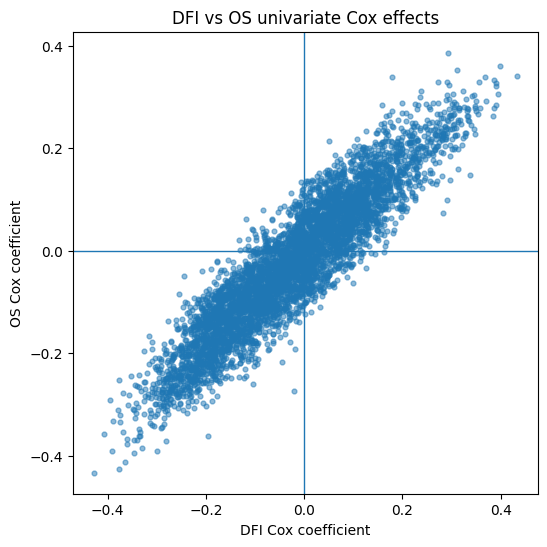

Spearman correlation: 0.9212808847304511
Pearson correlation: 0.9227818007633747


In [7]:
fig, ax = plt.subplots(figsize=(6, 6))

ax.scatter(merged["coef_dfi"], merged["coef_os"], s=12, alpha=0.5)
ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)

ax.set_xlabel("DFI Cox coefficient")
ax.set_ylabel("OS Cox coefficient")
ax.set_title("DFI vs OS univariate Cox effects")

plt.show()

spearman_corr = merged[["coef_dfi", "coef_os"]].corr(method="spearman").iloc[0, 1]
pearson_corr = merged[["coef_dfi", "coef_os"]].corr(method="pearson").iloc[0, 1]

print("Spearman correlation:", spearman_corr)
print("Pearson correlation:", pearson_corr)


In [8]:
primary_n = 400
secondary_n = 200
overlap_n = 500
max_candidates = 600

dfi_primary = dfi_ranked.head(primary_n).copy()
dfi_primary["candidate_source"] = "dfi_top400"

os_secondary = os_ranked.head(secondary_n).copy()
os_secondary["candidate_source"] = "os_top200"

overlap_same_direction = merged[
    (merged["same_direction"]) &
    (merged["gene"].isin(set(dfi_ranked.head(overlap_n)["gene"]))) &
    (merged["gene"].isin(set(os_ranked.head(overlap_n)["gene"])))
].copy()

overlap_same_direction = overlap_same_direction.sort_values("combined_rank_score")
overlap_same_direction["candidate_source"] = "dfi_os_top500_same_direction"

candidate_genes = pd.concat([
    dfi_primary[["gene", "gene_symbol_clean", "candidate_source"]],
    os_secondary[["gene", "gene_symbol_clean", "candidate_source"]],
    overlap_same_direction[["gene", "gene_symbol_clean", "candidate_source"]],
], axis=0)

candidate_genes = (
    candidate_genes
    .drop_duplicates("gene", keep="first")
    .head(max_candidates)
    .copy()
)

candidate_details = candidate_genes.merge(
    merged,
    on=["gene", "gene_symbol_clean"],
    how="left"
)

candidate_details["candidate_rank"] = np.arange(1, candidate_details.shape[0] + 1)

print("Candidate genes for Markov Blanket:", candidate_details.shape[0])
display(candidate_details.head(50))


Candidate genes for Markov Blanket: 475


,gene,gene_symbol_clean,candidate_source,coef_dfi,hr_per_sd_dfi,p_dfi,q_dfi,c_index_dfi,coef_os,hr_per_sd_os,p_os,q_os,c_index_os,same_direction,combined_rank_score,candidate_rank
0,CYP4V2_3,CYP4V2,dfi_top400,-0.427977,0.651826,1.249002e-07,0.000625,0.660155,-0.433520,0.648223,0.000001,0.006389,0.664668,True,2.0,1
1,FMO5_3,FMO5,dfi_top400,-0.378535,0.684864,2.021861e-06,0.003678,0.630441,-0.310540,0.733051,0.000303,0.045277,0.622292,True,34.0,2
2,MEX3A_3,MEX3A,dfi_top400,0.432622,1.541293,2.235926e-06,0.003678,0.616922,0.341269,1.406731,0.000256,0.045277,0.614856,True,30.0,3
3,TRIP13_3,TRIP13,dfi_top400,0.385792,1.470778,4.049608e-06,0.003678,0.624647,0.334060,1.396627,0.000252,0.045277,0.605661,True,30.0,4
4,APOBEC3Z3_4,APOBEC3Z3,dfi_top400,-0.396102,0.672938,5.474186e-06,0.003678,0.637201,-0.291369,0.747240,0.001289,0.063455,0.607580,True,104.0,5
5,GPR34_3,GPR34,dfi_top400,-0.391738,0.675881,6.018807e-06,0.003678,0.627544,-0.391796,0.675842,0.000034,0.029354,0.631247,True,10.0,6
6,DNA2_3,DNA2,dfi_top400,0.394110,1.483064,6.485603e-06,0.003678,0.619150,0.305845,1.357772,0.000800,0.060049,0.606460,True,73.0,7
7,CBX7_3,CBX7,dfi_top400,-0.389593,0.677332,6.780793e-06,0.003678,0.634007,-0.331935,0.717534,0.000324,0.046346,0.639722,True,43.0,8
8,LOC477699_3,LOC477699,dfi_top400,-0.368497,0.691773,6.850632e-06,0.003678,0.605556,-0.278054,0.757256,0.002220,0.075645,0.587111,True,154.0,9
9,ZMAT1_3,ZMAT1,dfi_top400,-0.374873,0.687377,7.356664e-06,0.003678,0.625650,-0.320370,0.725880,0.000575,0.051429,0.605261,True,64.0,10


In [9]:
candidate_path = RESULTS_DIR / "GSE238110_mb_candidate_genes_from_univariate_cox.csv"
candidate_details.to_csv(candidate_path, index=False)

overlap_path = RESULTS_DIR / "GSE238110_dfi_os_univariate_cox_overlap_summary.csv"
overlap_summary.to_csv(overlap_path, index=False)

merged_path = RESULTS_DIR / "GSE238110_dfi_os_univariate_cox_merged.csv"
merged.to_csv(merged_path, index=False)

print("Saved candidate genes:")
print(candidate_path)

print("Saved overlap summary:")
print(overlap_path)

print("Saved merged DFI/OS results:")
print(merged_path)


Saved candidate genes:
C:\Users\olegk\Desktop\paper4_sarcoma_dog\results\tables\GSE238110_mb_candidate_genes_from_univariate_cox.csv
Saved overlap summary:
C:\Users\olegk\Desktop\paper4_sarcoma_dog\results\tables\GSE238110_dfi_os_univariate_cox_overlap_summary.csv
Saved merged DFI/OS results:
C:\Users\olegk\Desktop\paper4_sarcoma_dog\results\tables\GSE238110_dfi_os_univariate_cox_merged.csv
